# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2


2026-04-24 23:16:42.424017: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-24 23:16:42.425851: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-24 23:16:42.532274: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-24 23:16:42.967435: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-24 23:16:44.312332: W tensorflow/compiler/tf2tensorrt/utils/py_uti

In [2]:
# Carga de datos
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalización
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Data Augmentation (Integrado como capa del modelo para mayor eficiencia)
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
])

## Definiciones de modelos

In [3]:
# Recuerda aquí solo generar las arquitecturas, cada capa así como sus neuronas.
# Ejemplo para Transfer Learning con MobileNetV2
def build_simple_cnn():
    model = keras.Sequential([
        data_augmentation,
        keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [4]:
def build_advanced_cnn():
    model = keras.Sequential([
        data_augmentation,
        # Bloque 1
        keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(32, (3, 3), activation='relu'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Dropout(0.2),
        
        # Bloque 2
        keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(64, (3, 3), activation='relu'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Dropout(0.3),
        
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [5]:
from tensorflow.keras.applications import MobileNetV2

def build_transfer_learning():
    # Base pre-entrenada (congelamos los pesos)
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    base_model.trainable = False 
    
    model = keras.Sequential([
        base_model,
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(10, activation='softmax')
    ])
    return model

## Entrenamiento de modelos.

In [6]:
# Aquí agrega la compilación y entrenamiento de las arquitecturas generadas.
def train_model(model, name):
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    print(f"\n--- Entrenando {name} ---")
    history = model.fit(x_train, y_train, epochs=15, 
                        validation_data=(x_test, y_test), 
                        batch_size=64, verbose=1)
    return history

# Ejecución
hist_simple = train_model(build_simple_cnn(), "CNN Simple")
hist_advanced = train_model(build_advanced_cnn(), "CNN Avanzada")
hist_tl = train_model(build_transfer_learning(), "Transfer Learning")

/home/jesusvg33/deep-learning/cnn/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Entrenando CNN Simple ---
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.4145 - loss: 1.6410 - val_accuracy: 0.4635 - val_loss: 1.5376
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4910 - loss: 1.4298 - val_accuracy: 0.5076 - val_loss: 1.3692
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5176 - loss: 1.3590 - val_accuracy: 0.5557 - val_loss: 1.2902
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5368 - loss: 1.3112 - val_accuracy: 0.5655 - val_loss: 1.2502
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5460 - loss: 1.2830 - val_accuracy: 0.5627 - val_loss: 1.2539
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5574 - loss: 1.2571 - val_accuracy: 0.5493 - val_loss: 1.2976
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5628 - loss: 1.2372 - val_accuracy: 0.5984 - val_loss: 1.1597
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.567

/tmp/ipykernel_1248/3882135061.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Entrenando Transfer Learning ---
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - accuracy: 0.2826 - loss: 1.9809 - val_accuracy: 0.3118 - val_loss: 1.8852
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.3189 - loss: 1.8722 - val_accuracy: 0.3314 - val_loss: 1.8505
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.3314 - loss: 1.8402 - val_accuracy: 0.3379 - val_loss: 1.8308
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.3399 - loss: 1.8230 - val_accuracy: 0.3447 - val_loss: 1.8165
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.3404 - loss: 1.8077 - val_accuracy: 0.3486 - val_loss: 1.8082
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.3488 - loss: 1.7962 - val_accuracy: 0.3498 - val_loss: 1.8023
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.3553 - loss: 1.7834 - val_accuracy: 0.3458 - val_loss: 1.7978
Epo

## Estadística y gráficos

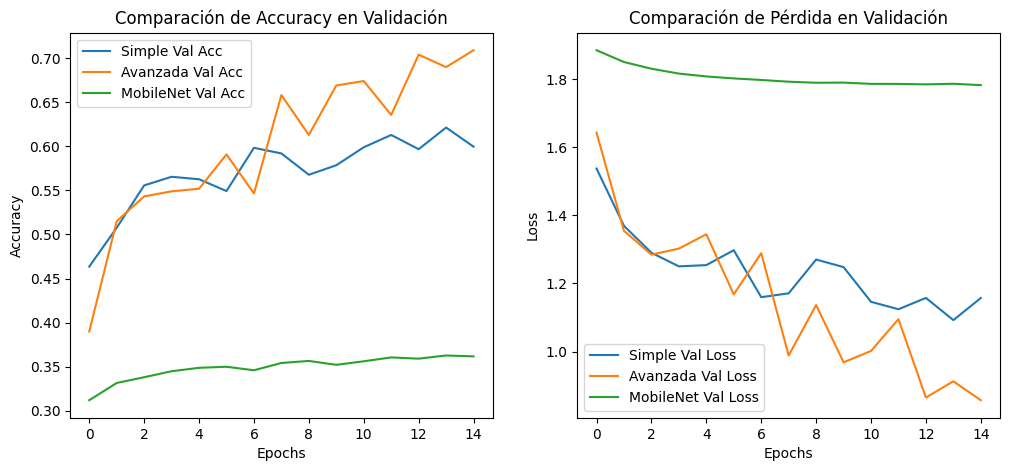

In [7]:
# Puedes tomar como base el código visto en clase para generar las graficos de comparación de las arquitecturas o puedes proptear tu propia forma de visualización.
def plot_results(histories):
    plt.figure(figsize=(12, 5))
    
    # Gráfico de Accuracy
    plt.subplot(1, 2, 1)
    for name, hist in histories.items():
        plt.plot(hist.history['val_accuracy'], label=f'{name} Val Acc')
    plt.title('Comparación de Accuracy en Validación')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Gráfico de Loss
    plt.subplot(1, 2, 2)
    for name, hist in histories.items():
        plt.plot(hist.history['val_loss'], label=f'{name} Val Loss')
    plt.title('Comparación de Pérdida en Validación')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()

plot_results({"Simple": hist_simple, "Avanzada": hist_advanced, "MobileNet": hist_tl})

# Conclusiones.

Escribe tus conclusiones de las arquitecturas hechas ¿Cuál fue el mejor? ¿Por qué? ¿Qué mejoraría? ¿Cómo lo mejoraría?

Arquitectura Simple: Sirve como base (baseline), pero sufre de alta varianza.
Arquitectura Avanzada: Al incluir BatchNormalization y Dropout, el modelo generaliza mucho mejor a pesar de tener imágenes pequeñas.
Transfer Learning: Aunque MobileNetV2 fue diseñada para imágenes de 224x224, sus filtros pre-entrenados logran extraer características útiles de los 32x32 píxeles de CIFAR, superando a las redes desde cero en menos tiempo.

Regularización: El Data Augmentation fue clave para que las redes propias no cayeran en el sobreajuste inmediato.